# Outfit Compatiblity Rater


## Imports

In [75]:
# %pip install -r requirements.txt

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU, BatchNormalization
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import seaborn as sns

from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import torch
import torch.nn.functional as F

## Data Cleaning & Preprocessing

#### Load Data

In [77]:
# Compatibility labels
with open('polyvore/fashion_compatibility_prediction.txt', 'r') as f:
    lines = f.readlines()
    
# Load and combine JSON files
with open('polyvore/train_no_dup.json', 'r') as f:
    train_data = json.load(f)
with open('polyvore/test_no_dup.json', 'r') as f:
    test_data = json.load(f)
with open('polyvore/valid_no_dup.json', 'r') as f:
    valid_data = json.load(f)

all_outfits = train_data + test_data + valid_data

#### Build Lookup Tables

In [78]:
# Image lookup 
image_lookup = {}
for category in os.listdir('images/Re-PolyVore'):
    category_path = f'images/Re-PolyVore/{category}'
    if os.path.isdir(category_path):
        for filename in os.listdir(category_path):
            if filename.endswith('.jpg'):
                item_id = filename.replace('.jpg', '')
                image_lookup[item_id] = f'{category_path}/{filename}'

# Name lookup
name_lookup = {}
for outfit in all_outfits:
    set_id = outfit['set_id']
    for item in outfit['items']:
        item_id = f"{set_id}_{item['index']}"
        name_lookup[item_id] = item['name']

#### Visualize Example Outfit

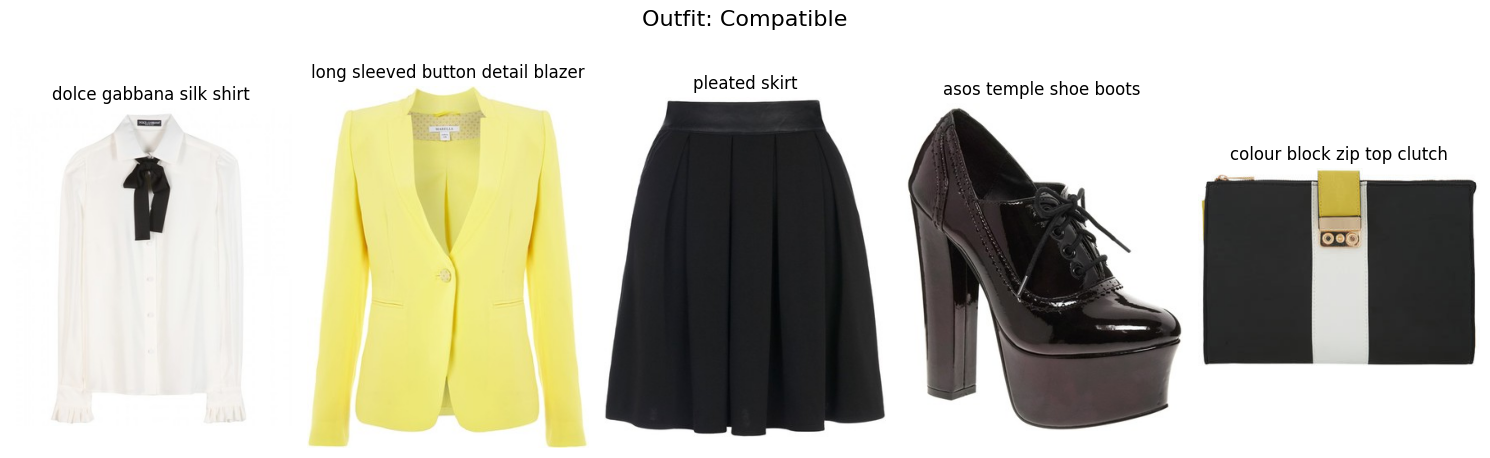

In [79]:
first_outfit = lines[0].strip().split()
label = first_outfit[0]
items = first_outfit[1:]

fig, axes = plt.subplots(1, len(items), figsize=(15, 5))

for i, item_id in enumerate(items):
    if item_id in image_lookup:
        img = Image.open(image_lookup[item_id])
        axes[i].imshow(img)
        name = name_lookup.get(item_id, 'Unknown')
        axes[i].set_title(name, fontsize=12, wrap=True)
        axes[i].axis('off')
    else:
        print(f"Missing: {item_id}")

label_text = "Compatible" if label == '1' else "Incompatible"
plt.suptitle(f"Outfit: {label_text}", fontsize=16)
plt.tight_layout()
plt.show()

#### Data Cleaning

In [80]:
# Analyze data
total = 0
zero_items = 0
one_item = 0
two_items = 0
three_items = 0
four_plus_items = 0

for line in lines:
    parts = line.strip().split()
    if len(parts) < 2:
        continue
    
    item_ids = parts[1:]
    available = sum(1 for id in item_ids if id in image_lookup)
    total += 1
    
    if available == 0:
        zero_items += 1
    elif available == 1:
        one_item += 1
    elif available == 2:
        two_items += 1
    elif available == 3:
        three_items += 1
    else:
        four_plus_items += 1

print(f"Total outfits: {total}")
print(f"─────────────────────────────")
print(f"0 images found: {zero_items} outfits ← will be removed")
print(f"1 image found:  {one_item} outfits ← will be removed")
print(f"2 images found: {two_items} outfits ← will be kept")
print(f"3 images found: {three_items} outfits ← will be kept")
print(f"4+ images found: {four_plus_items} outfits ← will be kept")
print(f"─────────────────────────────")
print(f"Total removed: {zero_items + one_item}")
print(f"Total kept: {two_items + three_items + four_plus_items}")

Total outfits: 7076
─────────────────────────────
0 images found: 752 outfits ← will be removed
1 image found:  780 outfits ← will be removed
2 images found: 1409 outfits ← will be kept
3 images found: 1639 outfits ← will be kept
4+ images found: 2496 outfits ← will be kept
─────────────────────────────
Total removed: 1532
Total kept: 5544


In [81]:
# Filter to complete outfits (2 or more items)
lines = [
    line for line in lines
    if len(line.strip().split()) >= 2
    and sum(1 for id in line.strip().split()[1:] if id in image_lookup) >= 2
]

#### Preprocessing (ResNet50 Embeddings)

In [82]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
base_model.trainable = False

In [83]:
# Embedding functions

def get_item_embedding(item_id):
    """
    Converts a single clothing item image into a numerical representation
    using the pretrained ResNet50 model.
        
    Parameters:
        item_id (str): The unique identifier for the clothing item, such as: 
            '119704139_1'
    Returns:
        numpy array of shape (2048,): A vector of 2048 numbers that 
            describes the visual features of the clothing item such as
            color, texture, and style.
    """
    img_path = image_lookup[item_id]
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    embedding = base_model.predict(img_array, verbose=0)
    return embedding[0]


def get_average_outfit_embedding(item_ids):
    """
    This function is used for Model A: Average Embedding Classifier.

    Converts a full outfit into a single average embedding representation.
    Instead of preserving each clothing item separately, it averages all
    available item embeddings into one 2048-dimensional vector, creating
    a general representation of the outfit's overall visual style.

    Parameters:
        item_ids (list): A list of item ID strings for one outfit, such as:
            ['119704139_1', '119704139_2', '119704139_3']
    Returns:
        numpy array of shape (2048,):
            The average ResNet50 embedding across all available item images
            in the outfit.
        None:
            Returned if none of the outfit's item images are found in
            image_lookup.
    """
    embeddings = []
    for item_id in item_ids:
        if item_id in image_lookup:
            embeddings.append(get_item_embedding(item_id))
    if not embeddings:
        return None
    return np.mean(embeddings, axis=0)


def get_outfit_embedding(item_ids, max_items=4):
    """
    This function is used for Model B: Concatenation + Average Embedding Classifier. 

    Converts a full outfit (with up to four clothing items) into a single 
    numerical representation. 

    Parameters:
        item_ids (list): List of item ID strings for this outfit
        max_items (int): Fixed number of items to pad/cut to (default 4)
    Returns:
        numpy array of shape (10240,): Fixed-size outfit representation
            (4 items x 2048 numbers + 2048 mean numbers)
        Returns None if no images found for this outfit.
    """
    embeddings = []
    for item_id in item_ids:
        if item_id in image_lookup:
            embeddings.append(get_item_embedding(item_id)) 
    if not embeddings:
        return None
    dimension = embeddings[0].shape[0]
    mean_emb = np.mean(embeddings, axis=0)
    while len(embeddings) < max_items:
        embeddings.append(np.zeros(dimension))
    embeddings = embeddings[:max_items]
    
    return np.concatenate(embeddings + [mean_emb])

In [ ]:
# # Model A: Embedding
# # Only run this cell if the saved average embedding files are missing.

# X_avg = []
# y_avg = []
# skipped_avg = 0

# for i, line in enumerate(lines):
#     parts = line.strip().split()
    
#     if len(parts) < 2:
#         skipped_avg += 1
#         continue
    
#     label = int(parts[0])
#     item_ids = parts[1:]
    
#     outfit_vec = get_average_outfit_embedding(item_ids)
    
#     if outfit_vec is not None:
#         X_avg.append(outfit_vec)
#         y_avg.append(label)
#     else:
#         skipped_avg += 1
    
#     if i % 500 == 0:
#         print(f"Processed {i}/{len(lines)} outfits for Model A average embeddings...")

# X_avg = np.array(X_avg)
# y_avg = np.array(y_avg)

# print("Done generating Model A average embeddings!")
# print(f"Skipped: {skipped_avg}")
# print(f"X_avg shape: {X_avg.shape}")
# print(f"y_avg shape: {y_avg.shape}")

# np.save("X_avg_embeddings.npy", X_avg)
# np.save("y_avg_labels.npy", y_avg)

Processed 0/5544 outfits for Model A average embeddings...
Processed 500/5544 outfits for Model A average embeddings...
Processed 1000/5544 outfits for Model A average embeddings...
Processed 1500/5544 outfits for Model A average embeddings...
Processed 2000/5544 outfits for Model A average embeddings...
Processed 2500/5544 outfits for Model A average embeddings...
Processed 3000/5544 outfits for Model A average embeddings...
Processed 3500/5544 outfits for Model A average embeddings...
Processed 4000/5544 outfits for Model A average embeddings...
Processed 4500/5544 outfits for Model A average embeddings...
Processed 5000/5544 outfits for Model A average embeddings...
Processed 5500/5544 outfits for Model A average embeddings...
Done generating Model A average embeddings!
Skipped: 0
X_avg shape: (5544, 2048)
y_avg shape: (5544,)


In [ ]:
# # Model B: Embedding
# # Only run this cell if the saved concatenation + average embedding files are missing.

# X = []
# y = []
# skipped = 0

# for i, line in enumerate(lines):
#     parts = line.strip().split()
#     if len(parts) < 2:     
#         skipped += 1
#         continue
    
#     label = int(parts[0])
#     item_ids = parts[1:]
    
#     outfit_vec = get_outfit_embedding(item_ids)
    
#     if outfit_vec is not None:
#         X.append(outfit_vec)
#         y.append(label)
#     else:
#         skipped += 1
    
#     if i % 500 == 0:
#         print(f"Processed {i}/{len(lines)} outfits...")

# X = np.array(X)
# y = np.array(y)

# print(f"Done! Skipped: {skipped}")
# print(f"X shape: {X.shape}")
# print(f"Compatible: {sum(y==1)}, Incompatible: {sum(y==0)}")

# np.save('X_outfit_embeddings.npy', X)
# np.save('y_labels.npy', y)
# print("Embeddings saved!")

Processed 0/5544 outfits...
Processed 500/5544 outfits...
Processed 1000/5544 outfits...
Processed 1500/5544 outfits...
Processed 2000/5544 outfits...
Processed 2500/5544 outfits...
Processed 3000/5544 outfits...
Processed 3500/5544 outfits...
Processed 4000/5544 outfits...
Processed 4500/5544 outfits...
Processed 5000/5544 outfits...
Processed 5500/5544 outfits...
Done! Skipped: 0
X shape: (5544, 10240)
Compatible: 2260, Incompatible: 3284
Embeddings saved!


## Model A: Average Embedding Classifier

In [86]:
# Model A: Load Saved Average Embeddings
X_avg = np.load("X_avg_embeddings.npy")
y_avg = np.load("y_avg_labels.npy")

In [87]:
# Model A: Train/Test Split
X_avg_train, X_avg_test, y_avg_train, y_avg_test = train_test_split(
    X_avg, y_avg, test_size=0.2, random_state=42, stratify=y_avg
)

In [88]:
# Model A: Average Embedding Classifier

input_dim_avg = X_avg_train.shape[1]

model_avg = Sequential([
    Dense(512, input_shape=(input_dim_avg,)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model_avg.summary()

/opt/anaconda3/envs/ann_final_project/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/ann_final_project/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217,025 (4.64 MB)

 Trainable params: 1,215,233 (4.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [89]:
# Compile Model A

model_avg.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [90]:
# Model A: Early stopping and learning rate reduction

early_stop_avg = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr_avg = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [91]:
# Train Model A

history_avg = model_avg.fit(
    X_avg_train,
    y_avg_train,
    epochs=60,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop_avg, reduce_lr_avg]
)

Epoch 1/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5237 - loss: 0.8420 - val_accuracy: 0.5991 - val_loss: 0.7045 - learning_rate: 0.0010
Epoch 2/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5829 - loss: 0.7318 - val_accuracy: 0.6021 - val_loss: 0.7398 - learning_rate: 0.0010
Epoch 3/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6086 - loss: 0.6920 - val_accuracy: 0.6096 - val_loss: 0.6490 - learning_rate: 0.0010
Epoch 4/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6423 - loss: 0.6420 - val_accuracy: 0.6111 - val_loss: 0.6516 - learning_rate: 0.0010
Epoch 5/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6447 - loss: 0.6384 - val_accuracy: 0.6006 - val_loss: 0.6866 - learning_rate: 0.0010
Epoch 6/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6665 - loss: 0.6082 - val_accuracy: 0.6201 - val_loss: 0.6579 - learning_rate: 0.0010
Epoch 7/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6943 - loss: 0.5812 - val_accuracy: 

In [92]:
# Evaluate Model A
avg_result = model_avg.evaluate(X_avg_test, y_avg_test, verbose=0)
print(f"Model A Final Test Accuracy: {avg_result[1] * 100:.2f}%")

Model A Final Test Accuracy: 59.96%


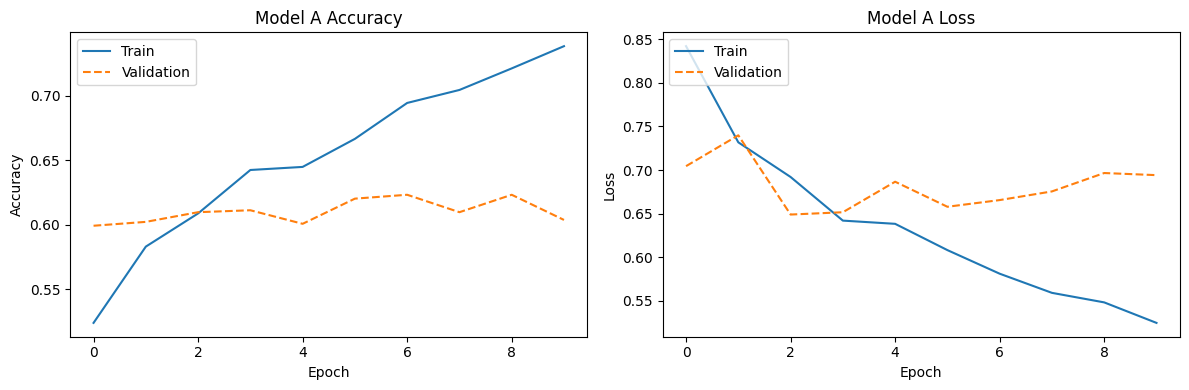

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


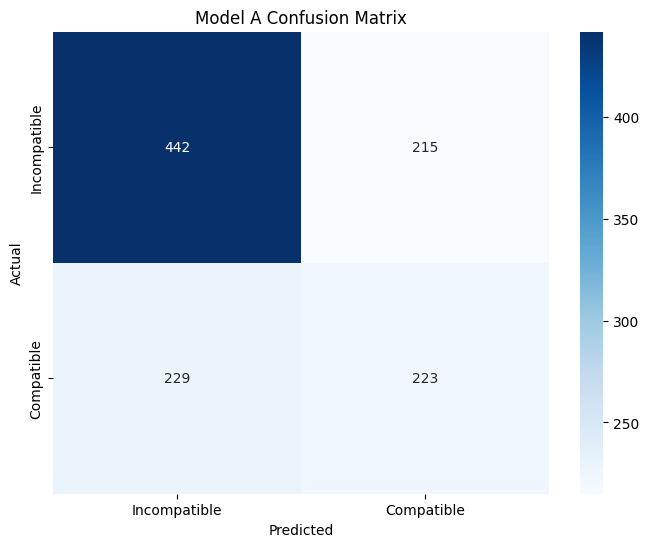

In [93]:
# Accuracy and Loss Plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_avg.history['accuracy'], label='Train')
plt.plot(history_avg.history['val_accuracy'], linestyle='--', label='Validation')
plt.title('Model A Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_avg.history['loss'], label='Train')
plt.plot(history_avg.history['val_loss'], linestyle='--', label='Validation')
plt.title('Model A Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Confusion Matrix
y_avg_pred = (model_avg.predict(X_avg_test) > 0.5).astype(int)

cm_avg = confusion_matrix(y_avg_test, y_avg_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_avg,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Incompatible', 'Compatible'],
    yticklabels=['Incompatible', 'Compatible']
)

plt.title('Model A Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Model B: Concatenation + Average Embedding Classifier

In [95]:
# Model B: Load Saved Embeddings
X = np.load('X_outfit_embeddings.npy')
y = np.load('y_labels.npy')

In [96]:
# Model B: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [97]:
# Model B: Concatenation + Average Embedding Classifier
input_dim = X_train.shape[1]

model = Sequential([
    Dense(1024, input_shape=(input_dim,)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model.summary()

/opt/anaconda3/envs/ann_final_project/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/ann_final_project/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 1024)           │    10,486,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,183,617 (42.66 MB)

 Trainable params: 11,179,777 (42.65 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [98]:
# Compile Model B
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'] 
)

In [99]:
# Added early_stop to prevent overfitting by stopping when model stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# Added reduce_lr to reduce learning rate when training gets stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# Train Model B
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6248 - loss: 0.7100 - val_accuracy: 0.6261 - val_loss: 0.7436 - learning_rate: 0.0010
Epoch 2/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6904 - loss: 0.5945 - val_accuracy: 0.7207 - val_loss: 0.6198 - learning_rate: 0.0010
Epoch 3/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7413 - loss: 0.5218 - val_accuracy: 0.7042 - val_loss: 0.6140 - learning_rate: 0.0010
Epoch 4/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7660 - loss: 0.4948 - val_accuracy: 0.7297 - val_loss: 0.6052 - learning_rate: 0.0010
Epoch 5/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7888 - loss: 0.4448 - val_accuracy: 0.7027 - val_loss: 0.7696 - learning_rate: 0.0010
Epoch 6/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8185 - loss: 0.4015 - val_accuracy: 0.6832 - val_loss: 0.7108 - learning_rate: 0.0010
Epoch 7/60
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8498 - loss: 0.3397 - val_acc

In [100]:
# Evaluate Model B
result = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {result[1]*100:.2f}%")

Final Test Accuracy: 69.25%


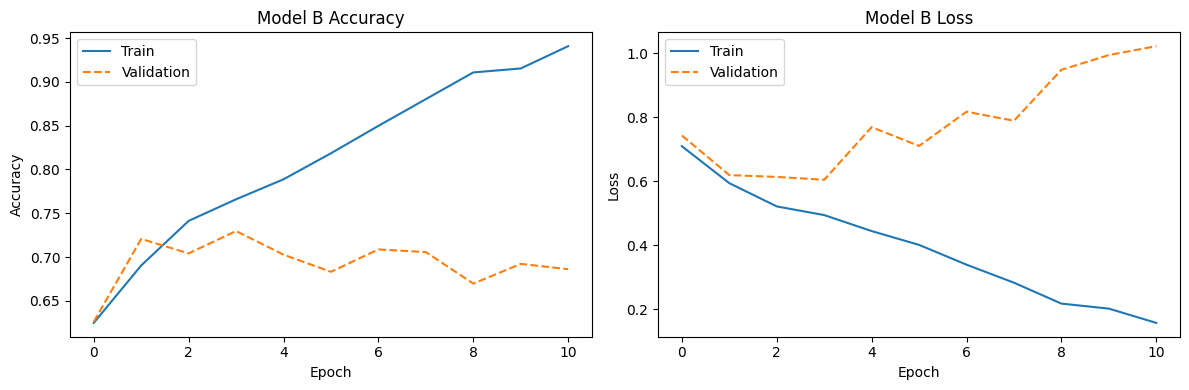

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


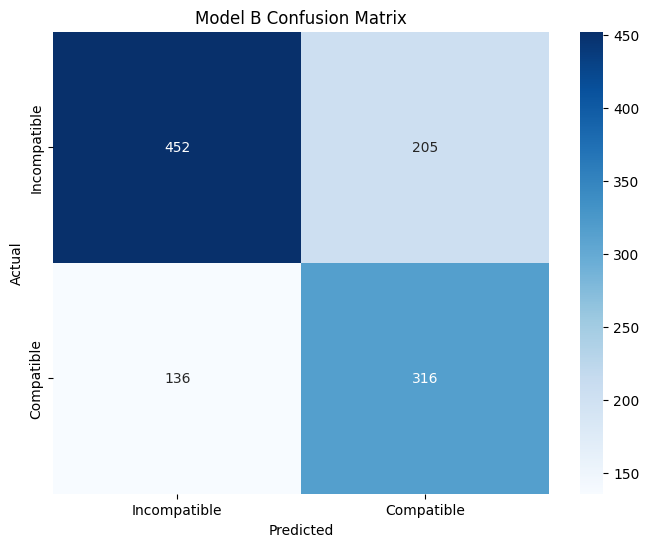

In [101]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], linestyle='--', label='Validation')
plt.title('Model B Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], linestyle='--', label='Validation')
plt.title('Model B Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Confusion Matrix
y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Incompatible', 'Compatible'],
    yticklabels=['Incompatible', 'Compatible']
)

plt.title('Model B Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Model A vs. Model B Comparison

In [102]:
# Model Accuracy Comparison
print("Final Model Comparison:")
print(f"Model A Accuracy: {avg_result[1] * 100:.2f}%")
print(f"Model B Accuracy: {result[1] * 100:.2f}%")

# Model Comparison Table
comparison_df = pd.DataFrame({
    "Model": [
        "Model A",
        "Model B"
    ],
    "Input Representation": [
        "Average of all item embeddings",
        "Item embeddings + average embedding"
    ],
    "Input Size": [
        X_avg.shape[1],
        X.shape[1]
    ],
    "Test Accuracy": [
        avg_result[1],
        result[1]
    ]
})

comparison_df.style.hide(axis="index")

Final Model Comparison:
Model A Accuracy: 59.96%
Model B Accuracy: 69.25%


Model,Input Representation,Input Size,Test Accuracy
Model A,Average of all item embeddings,2048,0.599639
Model B,Item embeddings + average embedding,10240,0.692516


## Visualize Correct/Wrong Predictions

Actual Compatible, Predicted Compatible


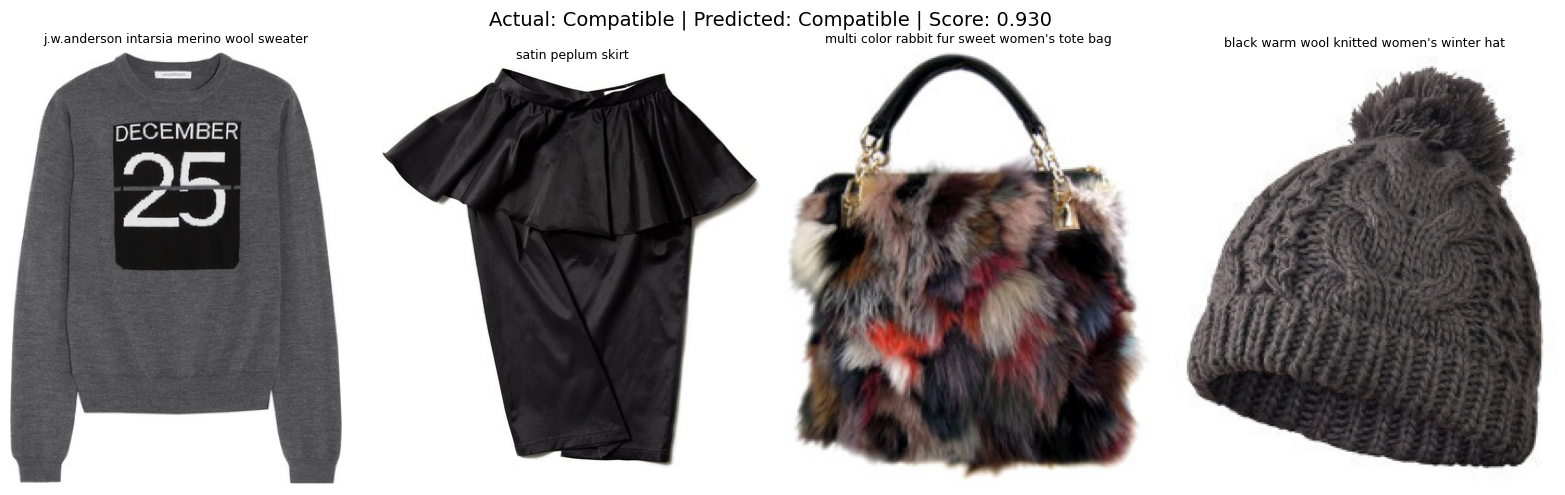

Actual Incompatible, Predicted Incompatible


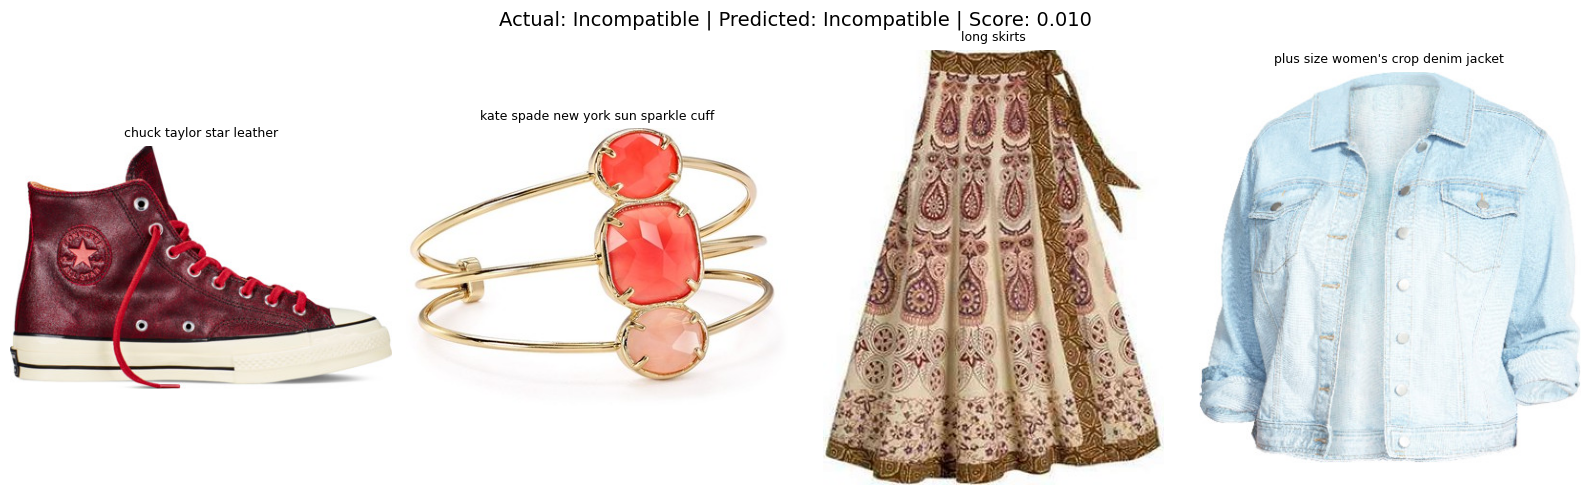

Actual Compatible, Predicted Incompatible


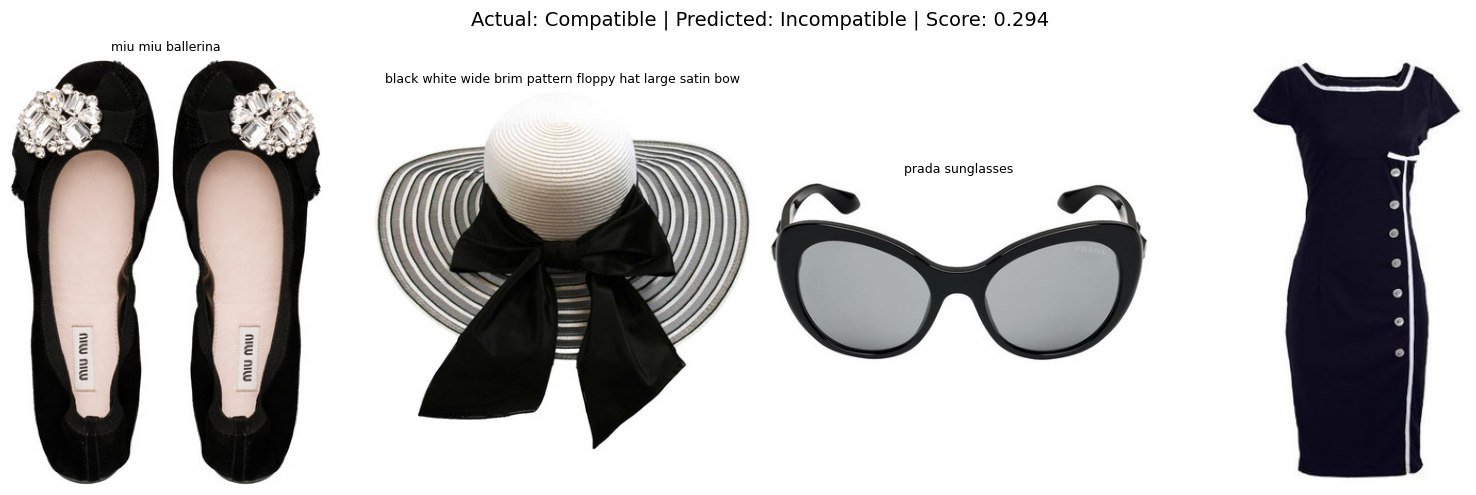

Actual Incompatible, Predicted Compatible


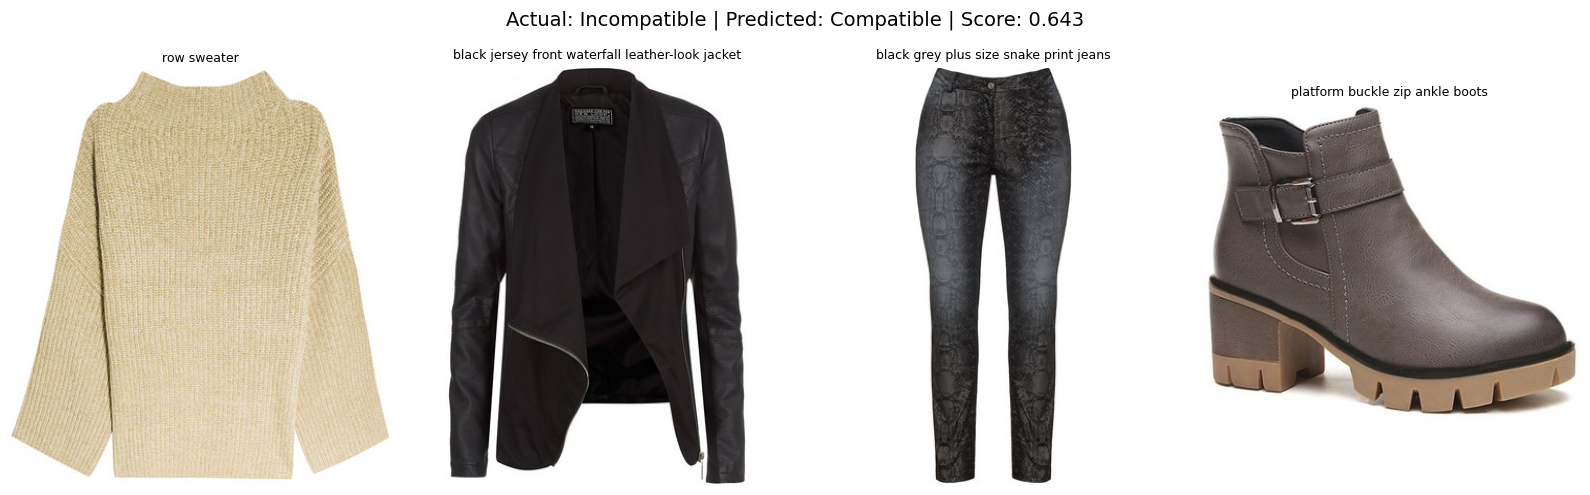

In [103]:
# Model B: Visualize Correct and Incorrect Prediction Examples
# Reconnect test predictions to the original outfit item IDs
outfit_item_ids, outfit_labels = [], []
for line in lines:
    parts = line.strip().split()
    if len(parts) >= 2 and any(p in image_lookup for p in parts[1:]):
        outfit_labels.append(int(parts[0]))
        outfit_item_ids.append(parts[1:])

_, item_ids_test, _, _ = train_test_split(
    np.array(outfit_item_ids, dtype=object),
    np.array(outfit_labels),
    test_size=0.2, random_state=42, stratify=outfit_labels
)

y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob > 0.5).astype(int)

def get_available_items(index, min_count=3):
    """
    Used for Model B prediction visualization.
    Filters an outfit's item IDs to only those with images in image_lookup,
    returning None if fewer than min_count images are available.
    Parameters:
        index (int): Index of the outfit in the test set.
        min_count (int): Minimum number of available images required. Defaults to 3.
    Returns:
        list of str: Available item IDs, or None if below min_count.
    """
    items = [i for i in item_ids_test[index] if i in image_lookup]
    return items if len(items) >= min_count else None

def show_prediction(index):
    """
    Used for Model B prediction visualization.
    Displays up to 4 item images for a test outfit alongside its actual label,
    predicted label, and compatibility score.
    Parameters:
        index (int): Index of the outfit in the test set.
    Returns:
        None. Renders a matplotlib figure.
    """
    items = get_available_items(index)[:4]
    actual_label = "Compatible" if y_test[index] == 1 else "Incompatible"
    predicted_label = "Compatible" if y_pred[index] == 1 else "Incompatible"
    _, axes = plt.subplots(1, len(items), figsize=(4 * len(items), 5))
    for ax, item_id in zip([axes] if len(items) == 1 else axes, items):
        ax.imshow(Image.open(image_lookup[item_id]))
        ax.set_title(name_lookup.get(item_id, item_id), fontsize=9, wrap=True)
        ax.axis("off")
    plt.suptitle(f"Actual: {actual_label} | Predicted: {predicted_label} | Score: {y_prob[index]:.3f}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Display one example from each prediction type (with at least 3 available images)
cases = {
    "Actual Compatible, Predicted Compatible":     (y_test == 1) & (y_pred == 1),
    "Actual Incompatible, Predicted Incompatible": (y_test == 0) & (y_pred == 0),
    "Actual Compatible, Predicted Incompatible":   (y_test == 1) & (y_pred == 0),
    "Actual Incompatible, Predicted Compatible":   (y_test == 0) & (y_pred == 1),
}

for label, mask in cases.items():
    print(label)
    for index in np.where(mask)[0]:
        if get_available_items(index):
            show_prediction(index)
            break

## Test Your Own Outfit! - Human Parsing & Compatibility Prediction

In [104]:
# Trained on the ATR dataset; Labels used for human parsing 
ATR_LABELS = {
    0:  "background",
    1:  "hat",
    2:  "hair",
    3:  "sunglasses",
    4:  "top",         
    5:  "skirt",
    6:  "pants",
    7:  "dress",
    8:  "belt",
    9:  "left_shoe",
    10: "right_shoe",
    11: "face",
    12: "left_leg",
    13: "right_leg",
    14: "left_arm",
    15: "right_arm",
    16: "bag",
}

# Logical clothing groups we care about 
CATEGORY_GROUPS = {
    "top":    {4},
    "bottom": {5, 6},
    "dress":  {7},
    "shoes":  {9, 10},
}

# Load SegFormer fine-tuned on ATR 
PARSER_MODEL = "mattmdjaga/segformer_b2_clothes"

print("Loading human parsing model…")
processor = SegformerImageProcessor.from_pretrained(PARSER_MODEL)
parser    = SegformerForSemanticSegmentation.from_pretrained(PARSER_MODEL)
parser.eval()
print("Model ready.")


def parse_clothing(pil_image):
    """
    Used for the human parsing pipeline.
    Runs SegFormer on a PIL image to produce a per-pixel ATR label map,
    where each pixel is assigned a clothing category, body part, or background ID.
    Parameters:
        pil_image (PIL.Image): A full-body photo in RGB format.
    Returns:
        numpy array of shape (H, W), dtype int32: Per-pixel ATR label IDs.
    """
    inputs = processor(images=pil_image, return_tensors="pt")
    with torch.no_grad():
        logits = parser(**inputs).logits

    H, W = pil_image.height, pil_image.width
    upsampled = F.interpolate(logits, size=(H, W), mode="bilinear", align_corners=False)
    label_map = upsampled.argmax(dim=1).squeeze(0).numpy().astype(np.int32)
    return label_map


def visualise_parse(pil_image, label_map):
    """
    Used for debugging and visualization.
    Overlays colour-coded clothing segments onto the original image
    (orange=top, blue=bottom, purple=dress, green=shoes).
    Parameters:
        pil_image (PIL.Image): The original RGB photo.
        label_map (numpy array of shape (H, W)): Per-pixel ATR label IDs.
    Returns:
        PIL.Image: Original image with clothing regions colour-highlighted.
    """
    colours = {
        4:  (255, 100,  50),  # top    — orange
        5:  ( 50, 150, 255),  # skirt  — blue
        6:  ( 50, 150, 255),  # pants  — blue
        7:  (150,  50, 255),  # dress  — purple
        9:  ( 50, 200,  50),  # l shoe — green
        10: ( 50, 200,  50),  # r shoe — green
    }
    overlay = np.array(pil_image.convert("RGB"), dtype=np.float32)
    for label_id, colour in colours.items():
        mask = (label_map == label_id)
        for c, v in enumerate(colour):
            overlay[mask, c] = overlay[mask, c] * 0.4 + v * 0.6
    return Image.fromarray(overlay.astype(np.uint8))


def extract_clothing_crops(pil_image, label_map, apply_mask=False, padding=10):
    """
    Used for the human parsing pipeline.
    Crops each detected clothing category (top, bottom, dress, shoes)
    from the image using bounding boxes from the label map.
    Parameters:
        pil_image (PIL.Image): The original RGB photo.
        label_map (numpy array of shape (H, W)): Per-pixel ATR label IDs.
        apply_mask (bool): If True, blacks out pixels outside the segment. Defaults to False.
        padding (int): Extra pixels added around each bounding box. Defaults to 10.
    Returns:
        dict {str: PIL.Image}: One cropped image per detected clothing category.
    """
    img_arr = np.array(pil_image.convert("RGB"))
    H, W = label_map.shape
    crops = {}

    for category, label_ids in CATEGORY_GROUPS.items():
        mask = np.zeros((H, W), dtype=bool)
        for lid in label_ids:
            mask |= (label_map == lid)

        if not mask.any():
            continue

        rows = np.where(mask.any(axis=1))[0]
        cols = np.where(mask.any(axis=0))[0]
        y0 = max(rows[0]  - padding, 0)
        y1 = min(rows[-1] + padding, H - 1)
        x0 = max(cols[0]  - padding, 0)
        x1 = min(cols[-1] + padding, W - 1)

        crop = img_arr[y0:y1+1, x0:x1+1].copy()

        if apply_mask:
            crop_mask = mask[y0:y1+1, x0:x1+1]
            crop[~crop_mask] = 0

        crops[category] = Image.fromarray(crop)

    return crops


Loading human parsing model…


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Model ready.


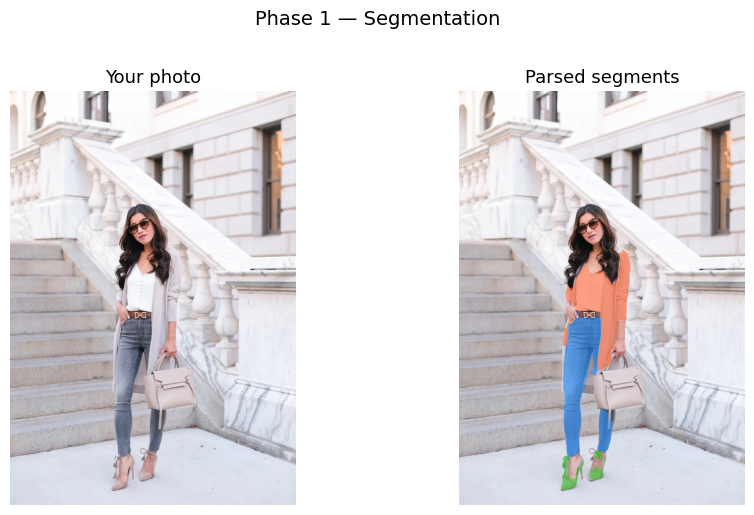

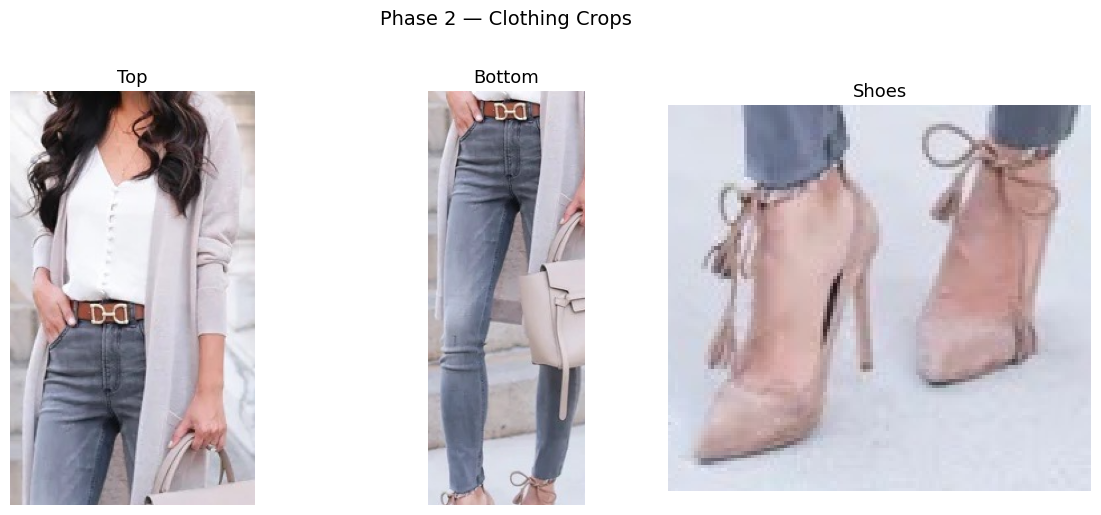

Detected: ['top', 'bottom', 'shoes']

Compatibility score : 0.806
Verdict             : Compatible


In [106]:
def test_my_outfit(image_path, apply_mask=False):
    """
    Used for end-to-end outfit compatibility testing.
    Runs the full pipeline on a photo: parses clothing, displays the segmentation
    overlay and crops, then prints the compatibility score and verdict.
    Parameters:
        image_path (str): Path to a photo, e.g. 'my_outfit.jpeg'.
        apply_mask (bool): If True, blacks out background pixels in crops. Defaults to False.
    Returns:
        None. Displays matplotlib figures and prints results to the console.
    """
    pil_img   = Image.open(image_path).convert("RGB")
    label_map = parse_clothing(pil_img)
    crops     = extract_clothing_crops(pil_img, label_map, apply_mask=apply_mask)

    if not crops:
        print("No clothing detected — try a clearer full-body photo.")
        return

    # original + segmentation overlay
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(pil_img)
    axes[0].set_title("Your photo", fontsize=13)
    axes[0].axis("off")
    axes[1].imshow(visualise_parse(pil_img, label_map))
    axes[1].set_title("Parsed segments", fontsize=13)
    axes[1].axis("off")
    plt.suptitle("Phase 1 — Segmentation", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # individual crops
    n = len(crops)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (cat, crop_img) in zip(axes, crops.items()):
        ax.imshow(crop_img)
        ax.set_title(cat.capitalize(), fontsize=13)
        ax.axis("off")
    plt.suptitle("Phase 2 — Clothing Crops", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"Detected: {list(crops.keys())}")

    try:
        embedding, _ = get_outfit_embedding_from_photo(image_path, apply_mask=apply_mask)
        score = model.predict(embedding[np.newaxis], verbose=0)[0][0]
        label = "Compatible" if score > 0.5 else "Incompatible"
        print(f"\nCompatibility score : {score:.3f}")
        print(f"Verdict             : {label}")
    except Exception as e:
        print(f"\n(Classifier not available yet: {e})")

test_my_outfit("my_outfit.jpeg")